In [1]:
# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Read in data, here the top scores for each protein/TRN pair (top RFI)
df = pd.read_csv("data/top_protein_trn_score_matrix.csv", index_col=0)

In [3]:
# Get the maximum score for each protein (row-wise)
top_scores = df.max(axis=1)

# Get the TRN corresponding to the maximum score for each protein
top_trns = df.idxmax(axis=1)

# Combine scores and TRNs into a single dataframe and sort by score (descending)
plot_df = (
    top_scores.rename("score")   # name the score column
    .to_frame()                  # convert Series to DataFrame
    .assign(top_trn=top_trns)    # add corresponding TRN
    .sort_values("score", ascending=False)  # rank proteins by top score
)

# Keep only the top 10% of proteins
n = len(plot_df)
top_n = int(0.10 * n)
plot_df = plot_df.iloc[:top_n]

# Extract arrays for plotting
sorted_vals = plot_df["score"].to_numpy()     # top scores (sorted)
trns_sorted = plot_df["top_trn"].to_numpy()   # corresponding TRNs

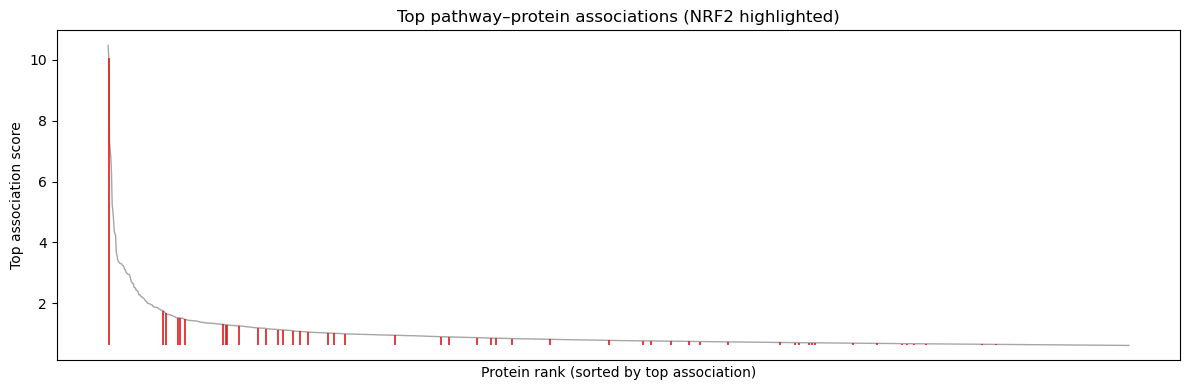

In [4]:
# Create x-axis as protein rank positions
x = np.arange(len(sorted_vals))

# Initialize figure and axis
fig, ax = plt.subplots(figsize=(12, 4))

# Plot all top scores as a grey line
ax.plot(x, sorted_vals, color="grey", linewidth=1, alpha=0.7)

# Create a boolean mask for proteins where the top TRN is NRF2
mask = trns_sorted == "NRF2"

# Highlight NRF2-associated proteins with vertical red lines
# Each line goes from the minimum score up to that protein’s score
ax.vlines(
    x[mask],
    ymin=sorted_vals.min(),
    ymax=sorted_vals[mask],
    color="#e41a1c",
    linewidth=1.2
)

# Set axis labels and title
ax.set_xlabel("Protein rank (sorted by top association)")
ax.set_ylabel("Top association score")
ax.set_title("Top pathway–protein associations (NRF2 highlighted)")

# Remove x-axis tick labels for cleaner visualization
ax.set_xticks([])

# Show plot
plt.tight_layout()
plt.show()

In [5]:
# Get counts of top 6 TRNs by occurrence in top 10% of proteins
top_k = 6
counts = plot_df["top_trn"].value_counts().head(top_k)

/tmp/kritis/46726554/g1416ood07.ll.unc.edu/ipykernel_2281368/1070043276.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha="right")


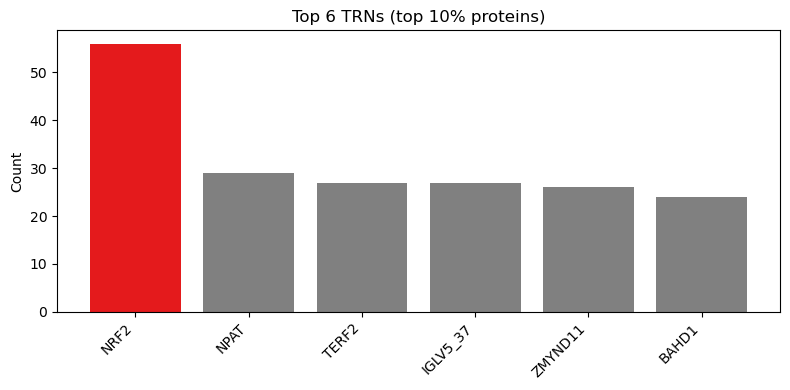

In [6]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 4))

# Assign colors: highlight NRF2 in red, others in grey
colors = ["#e41a1c" if trn == "NRF2" else "grey" for trn in counts.index]

# Plot bar chart of TRN counts
ax.bar(counts.index, counts.values, color=colors)

# Set labels and title
ax.set_ylabel("Count")
ax.set_title(f"Top {top_k} TRNs (top 10% proteins)")

# Rotate x-axis labels for readability
ax.set_xticklabels(counts.index, rotation=45, ha="right")

# Show plot
plt.tight_layout()
plt.show()